On reprend les Labs / TP du cours en l'appliquant à notre jeu de données.

In [4]:
import regex as re
import manuscripts
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [10]:
def get_clean_mss_id(mss_str):
    if not mss_str: return "Inconnu"
    # On coupe avant 'ff.' ou 'f.' ou 'f ' pour ne garder que la cote
    # Exemple: "Arundel 409. ff. 54-77" -> "Arundel 409"
    clean = re.split(r'\s+\.?f{1,2}\.', mss_str)[0]
    return clean.strip('. ')

def gen_catalog():
    # préférer la fonciton gen_catalog_mss_id()
    all_records = []
    for category, manuscripts_list in manuscripts.CORRESPONDENCE_OPERA_CORRECTED_MSS.items():
        for record in manuscripts_list:
            record_with_category = record.copy()
            record_with_category['category'] = category
            all_records.append(record_with_category)
    return pd.DataFrame(all_records)

def gen_catalog_mss_id():
    # Transformation du dictionnaire en DataFrame
    all_data = []
    for category, items in manuscripts.CORRESPONDENCE_OPERA_CORRECTED_MSS.items():
        for item in items:
            new_item = item.copy()
            new_item['category'] = category
            new_item['mss_id'] = get_clean_mss_id(item['mss'])
            all_data.append(new_item)

    return pd.DataFrame(all_data)

624
Graph with 624 nodes and 502 edges
Two different visualisations


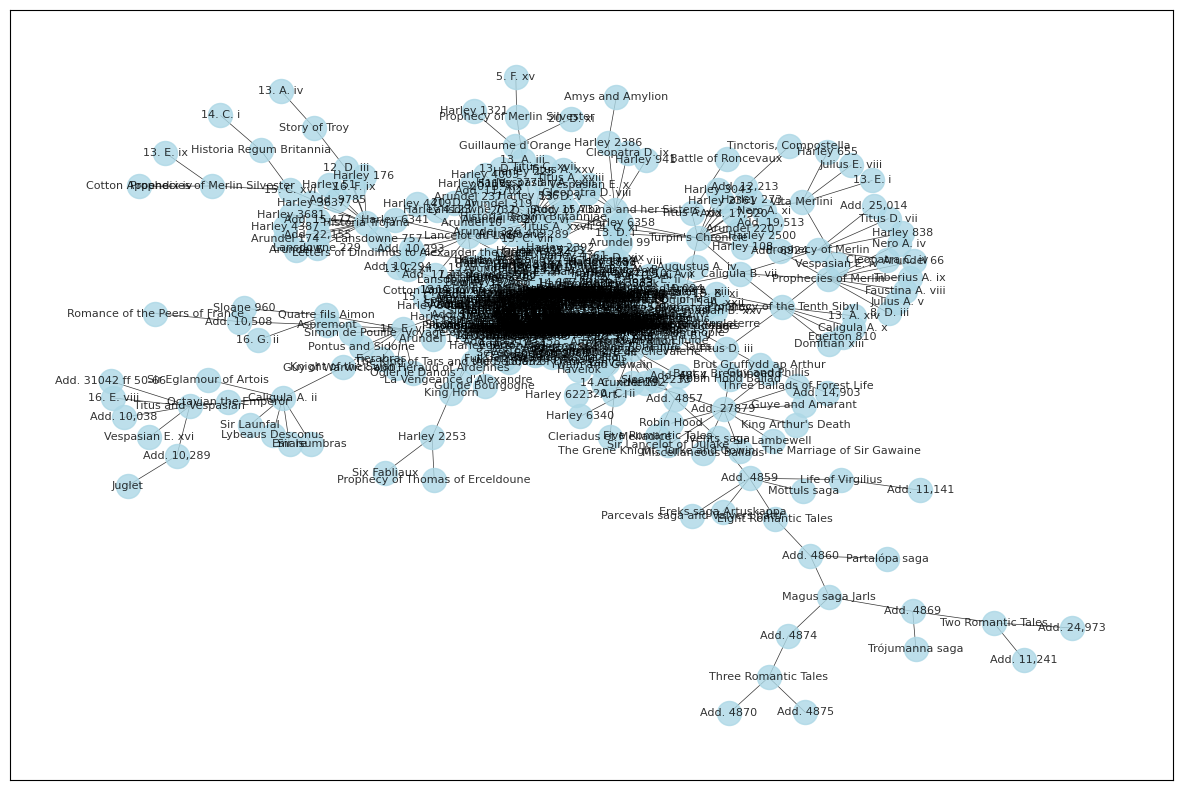

In [32]:
df_mss = gen_catalog_mss_id() 
manuscrits = df_mss['mss_id'].unique().tolist()
oeuvres = df_mss['name'].unique().tolist()

# Création graphe biparti
# wikipédia: 
#       When modelling relations between two different classes of objects, bipartite graphs very often arise naturally. 
#       For instance, a graph of football players and clubs, with an edge between a player and a club if the player has 
#       played for that club, is a natural example of an affiliation network, a type of bipartite graph used in social 
#       network analysis.
G = nx.Graph()
G.add_nodes_from(manuscrits, bipartite=0)
G.add_nodes_from(oeuvres, bipartite=1)

for _, row in df_mss.iterrows():
    G.add_edge(row['mss_id'], row['name'])

print(len(manuscrits) + len(oeuvres))
print(G)

print("Two different visualisations")

plt.figure(figsize=(15, 10))
plt.tight_layout()

nx.draw_networkx(G, 
    pos=nx.kamada_kawai_layout(G), #nx.spring_layout(G, k=3, iterations=50),
    node_size=300,
    node_color='lightblue',
    font_size=8,
    width=0.5,
    alpha=0.8
)
plt.show()

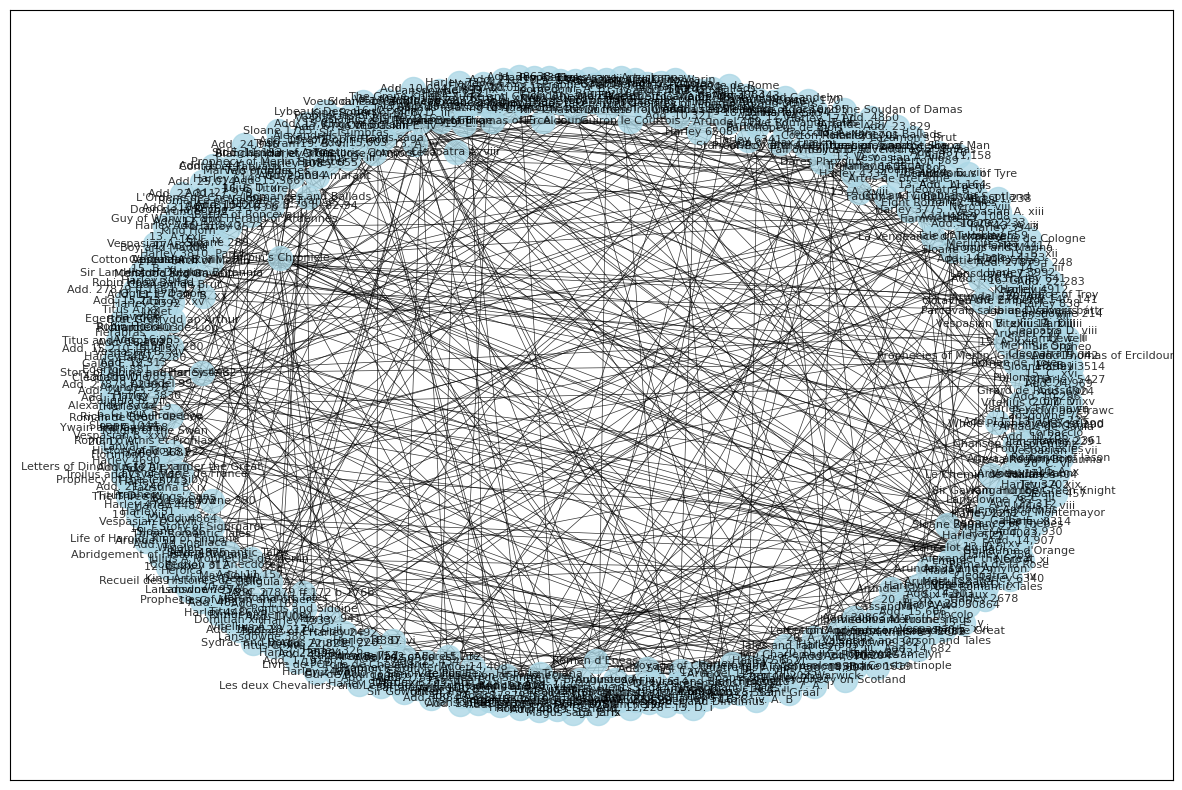

In [31]:
plt.figure(figsize=(15, 10))
plt.tight_layout()

nx.draw_networkx(G, 
    pos=nx.spring_layout(G, k=3, iterations=50),
    node_size=300,
    node_color='lightblue',
    font_size=8,
    width=0.5,
    alpha=0.8
)
plt.show()

In [37]:
G.nodes()

NodeView(('4. C. xi', '5. F. xv', '6. C. viii', '6. E. iii', '7. A. i', '8. B. iv', '8. D. iii', '8. F. ix', '9. B. ix', '10. A. x', '12. C. iv', '12. C. xii', '12. C. xx', '12. D. iii', '13. A. i', '13. A. iii', '13. A. iv', '13. A. v', '13. A. xiv', '13. A. xviii', '13. A. xxi', '13. C. xii', '13. D. i', '13. D. ii', '13. D. v', '13. E. i', '13. E. ix', '14. C. i', '14. C. xi', '14. E. ii', '14. E. iii', '15. A. x', '15. A. xxii', '15. B. xi', '15. C. vi', '15. C. xvi', '15. E. v', '15. E. vi', '16. C. iv. A. B', '16. C. xxiii', '16. D. iii. A. B', '16. E. viii', '16. E', '16. F. v', '16. F. ix', '16. G. ii', '17. B. xliii', '17. D. xv', '17. E. ii', '18. B. ii', '18. C. ii', '18. D. ii', '18. D. vi', '19. A. xviii', '19. B. vii', '19. B. xii', '19. B. xiii', '19. C. vii', '19. C. viii', '19. D. i', '19. E. ii', '19. E. iii', '20. A. v', '20. A. xvii', '20. B. xix', '20. B. xx', '20. C. ii', '20. C. vi', '20. D. ii', '20. D. iii', '20. D. iv', '20. D. vii', '20. D. xi', 'Julius A. v'

In [ ]:
G.edges()

EdgeView([('4. C. xi', 'Historia Regum Britanniae'), ('4. C. xi', "Turpin's Chronicle"), ('5. F. xv', 'Prophecy of Merlin Silvester'), ('6. C. viii', 'Dares Phrygius'), ('6. E. iii', 'Letters between Alexander and Dindimus'), ('7. A. i', 'Letters between Alexander and Dindimus'), ('8. B. iv', 'Alexandreis'), ('8. D. iii', 'Prophecies of Merlin'), ('8. F. ix', 'Guy of Warwick'), ('9. B. ix', 'Prophecy on Scotland'), ('10. A. x', 'Dares Phrygius'), ('12. C. iv', 'Alexander the Great'), ('12. C. xii', 'Prophecy'), ('12. C. xii', 'Fulk Fitz-Warin'), ('12. C. xii', 'Amya and Amylion'), ('12. C. xx', 'Tale of Two Lovers'), ('12. D. iii', 'Historia Trojana'), ('12. D. iii', 'Story of Troy'), ('13. A. i', 'Alexander the Great'), ('13. A. iii', 'Historia Regum Britanniae'), ('13. A. iii', 'Prophecy of Merlin Silvester'), ('13. A. iv', 'Story of Troy'), ('13. A. v', 'Alexander the Great'), ('13. A. v', 'Dares Phrygius'), ('13. A. v', 'Historia Regum Britanniae'), ('13. A. xiv', 'Prophecy of the 

In [54]:
print(list(G.neighbors('Historia Regum Britanniae')))
print(G.degree('Historia Regum Britanniae'))

['4. C. xi', '13. A. iii', '13. A. v', '13. D. i', '13. D. ii', '13. D. v', 'Nero D. viii', 'Galba E. xi', 'Vespasian A. xxiii', 'Vespasian E. x', 'Titus A. xviii', 'Titus A. xxv', 'Titus A. xxvii', 'Titus C. xvii', 'Cleopatra D. viii', 'Harley 225', 'Harley 536', 'Harley 3773', 'Harley 4003', 'Harley 4123', 'Harley 5115', 'Harley 6358', 'Lansdowne 732', 'Arundel 10', 'Arundel 237', 'Arundel 319', 'Arundel 326', 'Arundel 403', 'Arundel 409', 'Sloane 289', 'Add. 11,702', 'Add. 15,732']
32


In [61]:
print(list(nx.all_simple_paths(G, 'Historia Regum Britanniae', 'Lancelot du Lac')))
print(list(nx.all_simple_paths(G, 'Historia Regum Britanniae', 'Prophecies of Merlin')))
print(nx.shortest_path(G,  'Historia Regum Britanniae', 'Prophecies of Merlin'))

[]
[['Historia Regum Britanniae', '4. C. xi', "Turpin's Chronicle", 'Caligula B. vii', 'Prophecy of Merlin', 'Cleopatra C. iv', 'Prophecies of Merlin'], ['Historia Regum Britanniae', '4. C. xi', "Turpin's Chronicle", 'Caligula B. vii', 'Prophecies of Merlin'], ['Historia Regum Britanniae', '4. C. xi', "Turpin's Chronicle", 'Vespasian A. xiii', 'Apollonius of Tyre', 'Titus D. iii', 'Prophecy of the Tenth Sibyl', '15. A. xxii', 'Dares Phrygius', 'Caligula B. vii', 'Prophecy of Merlin', 'Cleopatra C. iv', 'Prophecies of Merlin'], ['Historia Regum Britanniae', '4. C. xi', "Turpin's Chronicle", 'Vespasian A. xiii', 'Apollonius of Tyre', 'Titus D. iii', 'Prophecy of the Tenth Sibyl', '15. A. xxii', 'Dares Phrygius', 'Caligula B. vii', 'Prophecies of Merlin'], ['Historia Regum Britanniae', '4. C. xi', "Turpin's Chronicle", 'Vespasian A. xiii', 'Apollonius of Tyre', 'Titus D. iii', 'Prophecy of the Tenth Sibyl', '15. B. xi', 'Dares Phrygius', 'Caligula B. vii', 'Prophecy of Merlin', 'Cleopatra

In [64]:
# Caractéristiques du graphe:

print("Connexe:", nx.is_connected(G))
if not nx.is_connected(G):
    print("Nombre de composantes connexes:", nx.number_connected_components(G))
print("Densité:", nx.density(G))

Connexe: False
Nombre de composantes connexes: 142
Densité: 0.002582623369140223


In [ ]:
# À FINIR